In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from statsmodels.stats.mediation import Mediation
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
from pingouin import ancova
import matplotlib.cm as cm
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

# 1 Load data from "2 BrainAge"

In [166]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Basic distributions

## 2.1 Data and Descriptives

In [167]:
main_test.head()

,ID,Age,Gender,IS,TPA,VPA,MPA,MVPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,BADA2009,BADASEG,BADDesikan
10,1001365,71.0,Female,11025,3396.9600,20.1600,514.0800,554.4000,2862.7200,594.0,240.0,240.0,20.0,73.0,28.2030,70.0,106.0,-3.595835,-5.824949,1.980465
17,1001748,48.0,Female,11025,3126.8160,265.3056,596.9376,1127.5488,2264.5728,462.0,0.0,2400.0,34.0,52.0,25.7857,75.0,124.0,4.049976,-2.298881,-4.984119
20,1001984,69.0,Female,11026,2468.4192,9.9936,579.6288,599.6160,1878.7968,693.0,960.0,0.0,26.0,76.0,25.7422,79.0,120.0,1.382366,-3.967790,4.538872
21,1002138,56.0,Female,11025,2465.2224,29.1168,427.0464,485.2800,2009.0592,2970.0,720.0,240.0,18.0,56.0,33.5680,75.0,134.0,-4.910601,-11.407986,18.847508
23,1002288,63.0,Female,11025,2559.7728,109.1376,704.4336,922.7088,1746.2016,264.0,960.0,0.0,30.0,85.0,27.4762,84.0,146.0,-5.202788,-4.301580,15.729320


Remove outliers on SR PA

In [168]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 563
5422


Remove people with Gender other than Male or Female

In [169]:
before = main_test.shape[0]
main_test = main_test[(main_test["Gender"] == "Female") | (main_test["Gender"] == "Male")]
after = main_test.shape[0]
print("Gender not Male or Female:", before-after)
print(after)

Gender not Male or Female: 0
5422


### 2.1.1 Test set

In [170]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Gender"] == "Female"]
male = main_test[main_test["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("LPA")
mean = female["LPA"].mean()
print("Female", mean)
std = female["LPA"].std()
print("Female",std)
mean = male["LPA"].mean()
print("Male",mean)
std = male["LPA"].std()
print("Male",std)

print("MPA")
mean = female["MPA"].mean()
print("Female", mean)
std = female["MPA"].std()
print("Female",std)
mean = male["MPA"].mean()
print("Male",mean)
std = male["MPA"].std()
print("Male",std)

print("VPA")
mean = female["VPA"].mean()
print("Female", mean)
std = female["VPA"].std()
print("Female",std)
mean = male["VPA"].mean()
print("Male",mean)
std = male["VPA"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

print("IS")
print("Female")
print(female["IS"].value_counts())
print("Male")
print(male["IS"].value_counts())

Number of females: 2898
NUmber of males: 2524
Age
Female 63.49482401656315
Female 7.556813291182583
Male 65.49207606973059
Male 7.824543474679913
LPA
Female 2056.1930434782607
Female 406.8644273491336
Male 1885.7437103011096
Male 405.84204331256376
MPA
Female 498.95904596273294
Female 226.04598507597225
Male 467.3088513470682
Male 219.2158898210811
VPA
Female 31.376486956521767
Female 41.49015419937569
Male 36.690498256735374
Male 47.658656646516
SRLPA
Female 788.5644927536232
Female 716.9490442462906
Male 753.3099841521395
Male 709.4481511450006
SRMPA
Female 658.1545893719807
Female 770.9382013505868
Male 607.4136291600634
Male 758.2566221943127
SRVPA
Female 476.40855762594896
Female 630.0607737527736
Male 553.9492868462758
Male 692.3469152768914
DBP
Female 79.28433402346445
Female 10.25709733932206
Male 83.24167987321711
Male 10.189301689365152
SBP
Female 133.13077984817116
Female 19.121772759199146
Male 140.57369255150556
Male 17.608384631991797
BMI
Female 25.811531090407172
Female 

### 2.1.2 Train set

In [171]:
# get mean and std for all variables for males and females seperately for the train set
female = main_train[main_train["Gender"] == "Female"]
male = main_train[main_train["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

print("IS")
print("Female")
print(female["IS"].value_counts())
print("Male")
print(male["IS"].value_counts())

Number of females: 11117
NUmber of males: 10325
Age
Female 63.836196815687686
Female 7.503871583194821
Male 65.00474576271186
Male 7.7586035249436
SRLPA
Female 984.1847981520185
Female 1033.3820726927277
Male 928.3805084745763
Male 1007.0754562865242
SRMPA
Female 837.8537014629853
Female 1113.6645965459636
Male 817.7301342725071
Male 1131.3713559199134
SRVPA
Female 574.130018699813
Female 920.1960026012333
Male 741.4853620955316
Male 1148.5582239428738
BMI
Female 26.138465982351878
Female 4.582669799430477
Male 27.191944284882588
Male 3.7562568482626655
DBP
Female 79.32254626489681
Female 10.228206380591313
Male 83.40178664173678
Male 10.089943983473264
SBP
Female 132.82763298130027
Female 19.06073106946566
Male 140.33489145112705
Male 17.42547072290952
HG
Female 25.921382796281254
Female 6.415775125843123
Male 42.48262473306154
Male 8.766859109259675
HR
Female 69.22216839453542
Female 10.393253848960265
Male 66.84958969564765
Male 11.43598977944362
IS
Female
11025    6408
11027    305

## 2.3 Age and BrainAge

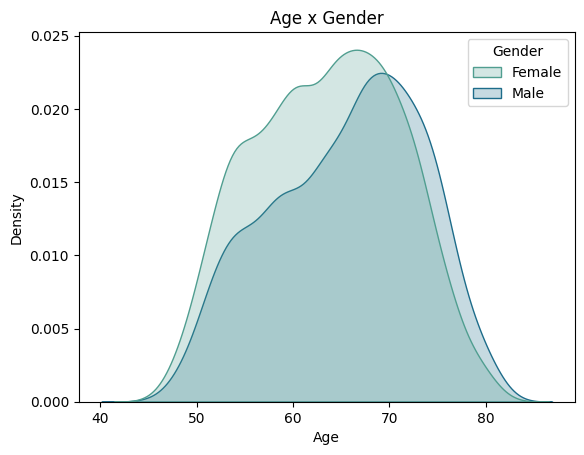

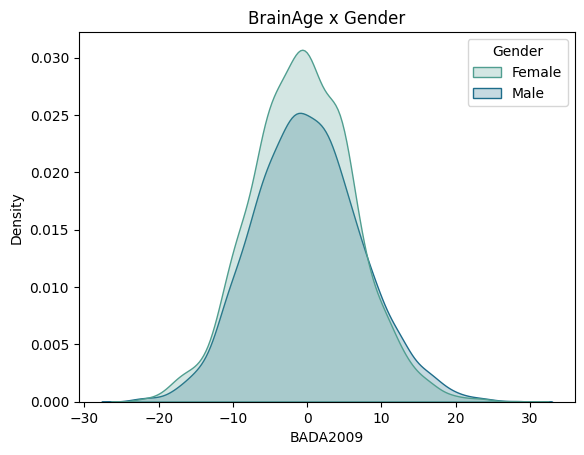

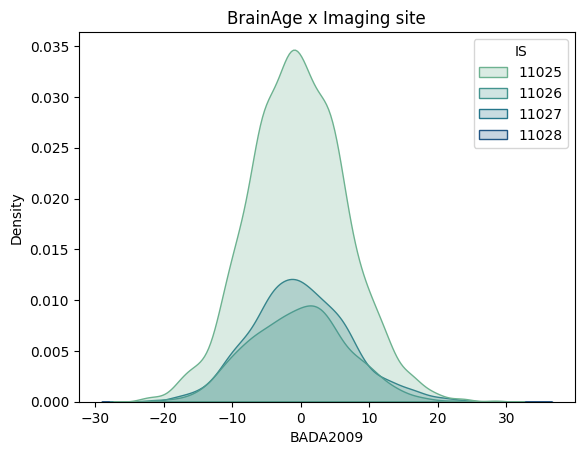

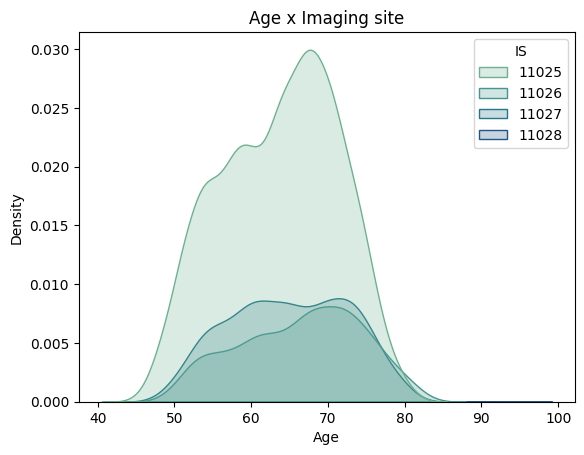

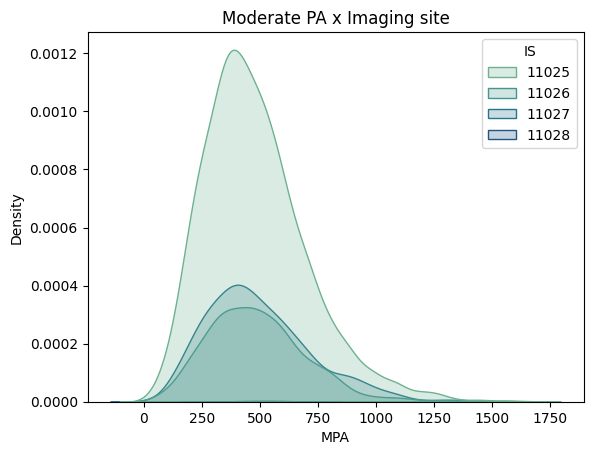

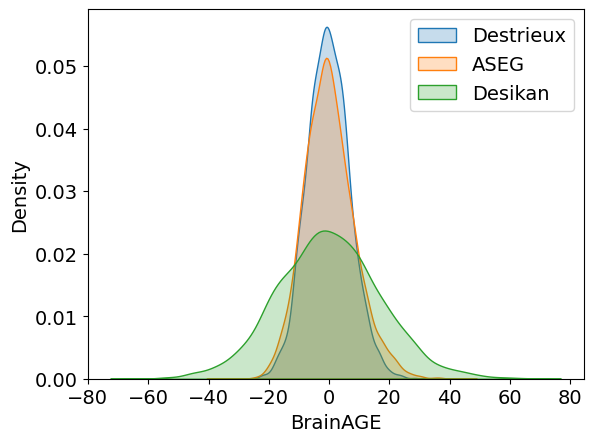

In [172]:
# plot Age by Gender
plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'Gender', fill=True, palette = "crest")
plt.title("Age x Gender")
plt.show()

# plot BrainAGE by Gender
plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'Gender', fill=True, palette = "crest")
plt.title("BrainAge x Gender")
plt.show()

# plot BrainAGE by Imaging Site
plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'IS', fill=True, palette = "crest")
plt.title("BrainAge x Imaging site")
plt.show()

# plot Age by Imaging Site
plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'IS', fill=True, palette = "crest")
plt.title("Age x Imaging site")
plt.show()

# plot Moderate PA by Imaging Site
plt.figure()
sns.kdeplot(data = main_test, x= 'MPA', hue = 'IS', fill=True, palette = "crest")
plt.title("Moderate PA x Imaging site")
plt.show()

# plot BrainAGE Segmentations
plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', fill=True, label="Destrieux")
sns.kdeplot(data = main_test, x= 'BADASEG', fill=True, label="ASEG")
sns.kdeplot(data = main_test, x= 'BADDesikan', fill=True, label="Desikan")
plt.xlabel("BrainAGE", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

## 2.4 Physical activity

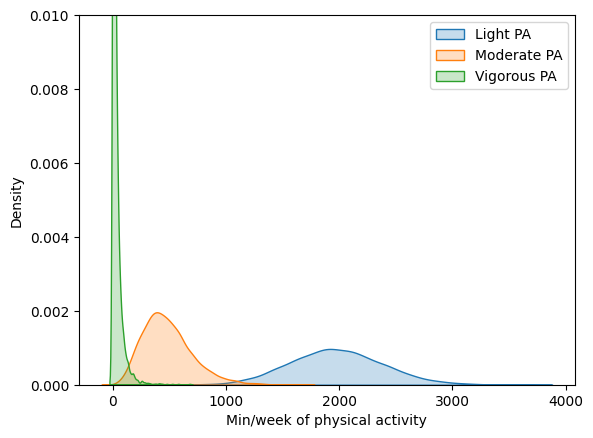

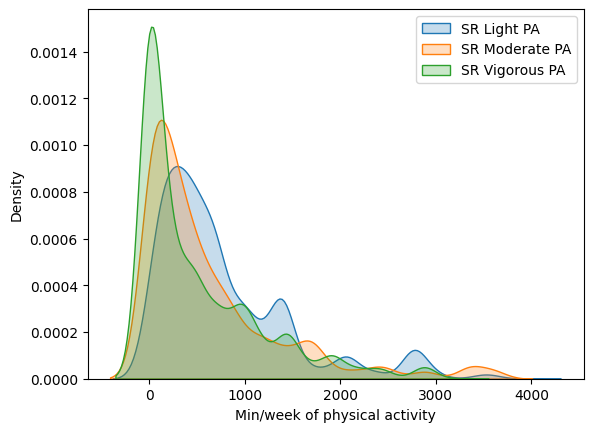

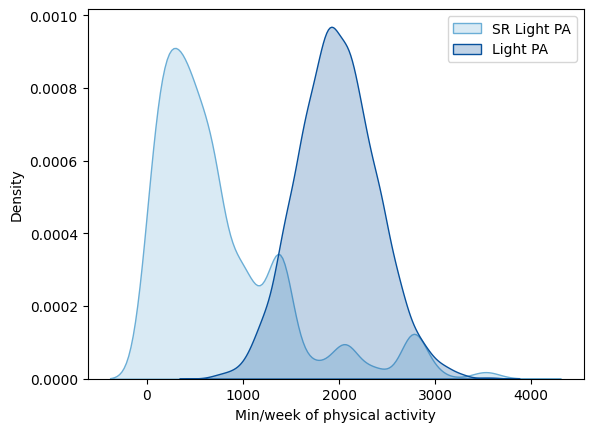

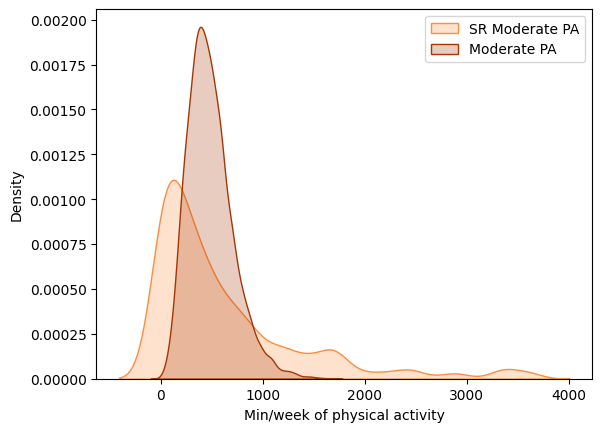

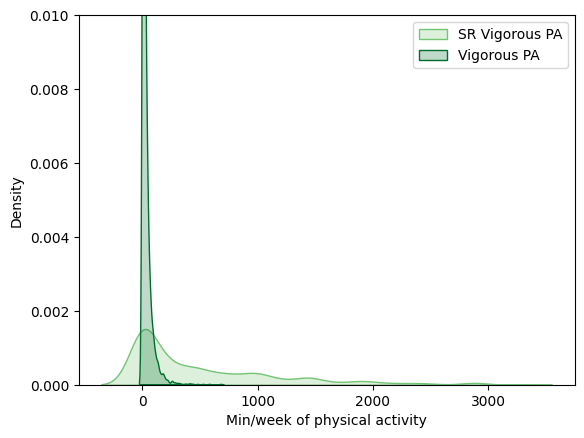

In [173]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately
plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.xticks(range(0,5000,1000))
plt.ylim(0,0.01)
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
plt.ylim(0,0.01)
plt.xticks(range(0,3500,1000))
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.show()

## 2.5 Fitness

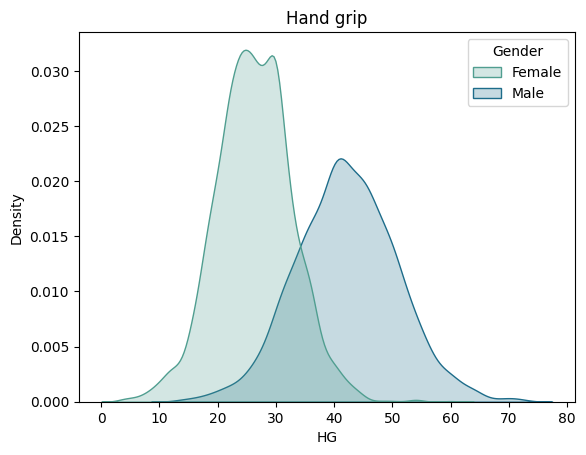

In [174]:
# plot dominant hand grip strength
plt.figure()
sns.kdeplot(data = main_test, x= 'HG', hue = 'Gender', fill=True, palette = "crest")
plt.title("Hand grip")
plt.show()

## 2.6 Health

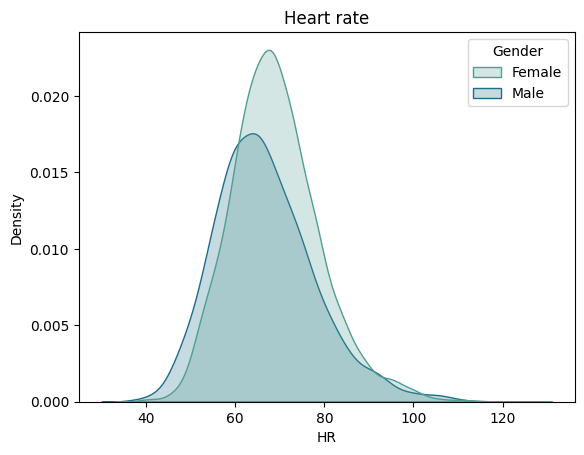

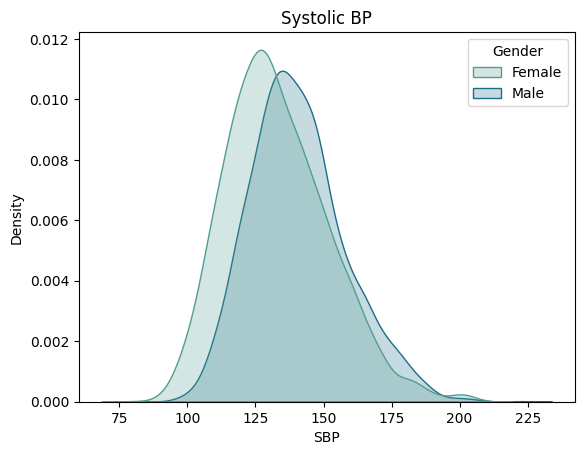

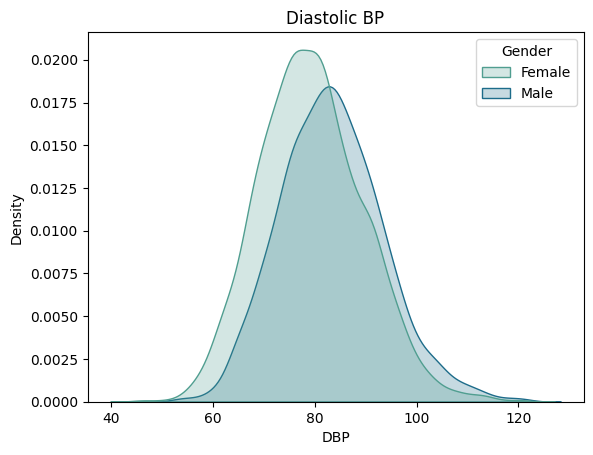

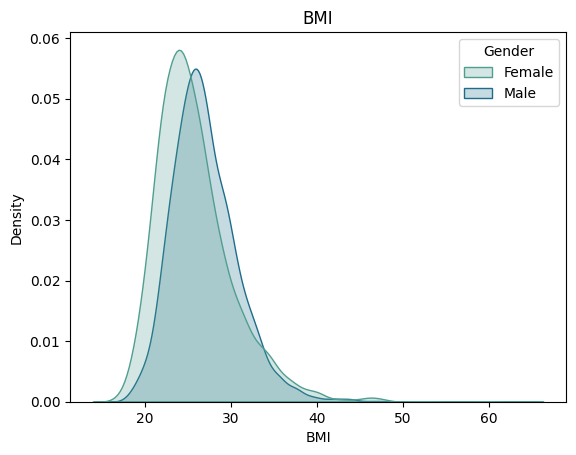

In [175]:
# plot Heart rate
plt.figure()
sns.kdeplot(data = main_test, x= 'HR', hue = 'Gender', fill=True, palette = "crest")
plt.title("Heart rate")
plt.show()

# plot systolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'SBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Systolic BP")
plt.show()

# plot diastolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'DBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Diastolic BP")
plt.show()

# plot BMI
plt.figure()
sns.kdeplot(data = main_test, x= 'BMI', hue = 'Gender', fill=True, palette = "crest")
plt.title("BMI")
plt.show()

# 3 Recode and compute variables

In [176]:
# recode Imaging site and Gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 1, '11026': 2,'11027': 3, '11028': 4})
main_test["Gender"] = main_test["Gender"].map({"Female":0, "Male":1})
main_test["Gender"] = main_test["Gender"].astype("int")
main_test = main_test.rename(columns={"BADA2009": "BA"})

# delete unused variables
del main_test["ID"]
del main_test["BADDesikan"]
del main_test["BADASEG"]
del main_test["MVPA"]
del main_test["TPA"]

# standardize all variables except Gender, Age, BrainAGE, Imaging site
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI"]], nan_policy='omit')

## 3.1 Compute Total and Moderate-Vigorous PA (not used)

In [177]:
# main_test["TPA"] = main_test["LPA"] + main_test["MPA"] + main_test["VPA"]
# main_test["SRTPA"] = main_test["SRLPA"] + main_test["SRMPA"] + main_test["SRVPA"]
main_test["MVPA"] = main_test["MPA"] + main_test["VPA"]
main_test["SRMVPA"] = main_test["SRMPA"] + main_test["SRVPA"]

## 3.2 Computed Combined Risk score

In [178]:
# combined risk score for self-report and accelerometer -> summing z-scores of best PA and health and fitness variables
# multiply fitness and PA by -1
main_test["CR"] = main_test["MPA"]*-1 + main_test["HG"]*-1 + main_test["DBP"] + main_test["HR"] + main_test["BMI"]
main_test["SRCR"] = main_test["SRMPA"]*-1 + main_test["HG"]*-1 + main_test["DBP"] + main_test["HR"] + main_test["BMI"]

## 3.3 Copy BrainAGE to end of dataframe

In [179]:
brainage = main_test["BA"]
del main_test["BA"]
main_test["BA"] = brainage

## 3.4 Remove effect of Age on all predictor variables (regression -> residuals)

In [180]:
model = ols("LPA ~ Age", data = main_test).fit()
main_test["LPA"] = model.resid

model = ols("MPA ~ Age", data = main_test).fit()
main_test["MPA"] = model.resid

model = ols("VPA ~ Age", data = main_test).fit()
main_test["VPA"] = model.resid

model = ols("SRLPA ~ Age", data = main_test).fit()
main_test["SRLPA"] = model.resid

model = ols("SRMPA ~ Age", data = main_test).fit()
main_test["SRMPA"] = model.resid

model = ols("SRVPA ~ Age", data = main_test).fit()
main_test["SRVPA"] = model.resid

model = ols("CR ~ Age", data = main_test).fit()
main_test["CR"] = model.resid

model = ols("SRCR ~ Age", data = main_test).fit()
main_test["SRCR"] = model.resid

model = ols("HR ~ Age", data = main_test).fit()
main_test["HR"] = model.resid

model = ols("DBP ~ Age", data = main_test).fit()
main_test["DBP"] = model.resid

model = ols("SBP ~ Age", data = main_test).fit()
main_test["SBP"] = model.resid

model = ols("BMI ~ Age", data = main_test).fit()
main_test["BMI"] = model.resid

model = ols("HG ~ Age", data = main_test).fit()
main_test["HG"] = model.resid

##

# model = ols("TPA ~ Age", data = main_test).fit()
# main_test["TPA"] = model.resid

model = ols("MVPA ~ Age", data = main_test).fit()
main_test["MVPA"] = model.resid

# model = ols("SRTPA ~ Age", data = main_test).fit()
# main_test["SRTPA"] = model.resid

model = ols("SRMVPA ~ Age", data = main_test).fit()
main_test["SRMVPA"] = model.resid

## 3.5 Descriptives for combined risk score (only test)

In [181]:
female = main_test[main_test["Gender"] == 0]
male = main_test[main_test["Gender"]== 1]

print("CR")
mean = female["CR"].mean()
print("Female", mean)
std = female["CR"].std()
print("Female",std)
mean = male["CR"].mean()
print("Male",mean)
std = male["CR"].std()
print("Male",std)

print("SRCR")
mean = female["SRCR"].mean()
print("Female", mean)
std = female["SRCR"].std()
print("Female",std)
mean = male["SRCR"].mean()
print("Male",mean)
std = male["SRCR"].std()
print("Male",std)

CR
Female 0.46052548845812996
Female 2.5878218798161208
Male -0.528765002199558
Male 2.463583075921431
SRCR
Female 0.45417905586325874
Female 2.468481169869264
Male -0.5214781711139967
Male 2.431580085510881


In [182]:
# reorder dataframe
main_test = main_test[['Age', 'Gender', 'IS' , 'LPA', 'MPA', 'VPA', 'MVPA', 'SRLPA', 'SRMPA', 'SRVPA', 'SRMVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', 'CR', 'SRCR', 'BA']]

# 4 Correlation heatmap

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'Gender'),
  Text(0, 2.5, 'IS'),
  Text(0, 3.5, 'LPA'),
  Text(0, 4.5, 'MPA'),
  Text(0, 5.5, 'VPA'),
  Text(0, 6.5, 'MVPA'),
  Text(0, 7.5, 'SRLPA'),
  Text(0, 8.5, 'SRMPA'),
  Text(0, 9.5, 'SRVPA'),
  Text(0, 10.5, 'SRMVPA'),
  Text(0, 11.5, 'HG'),
  Text(0, 12.5, 'HR'),
  Text(0, 13.5, 'BMI'),
  Text(0, 14.5, 'DBP'),
  Text(0, 15.5, 'SBP'),
  Text(0, 16.5, 'CR'),
  Text(0, 17.5, 'SRCR'),
  Text(0, 18.5, 'BA')])

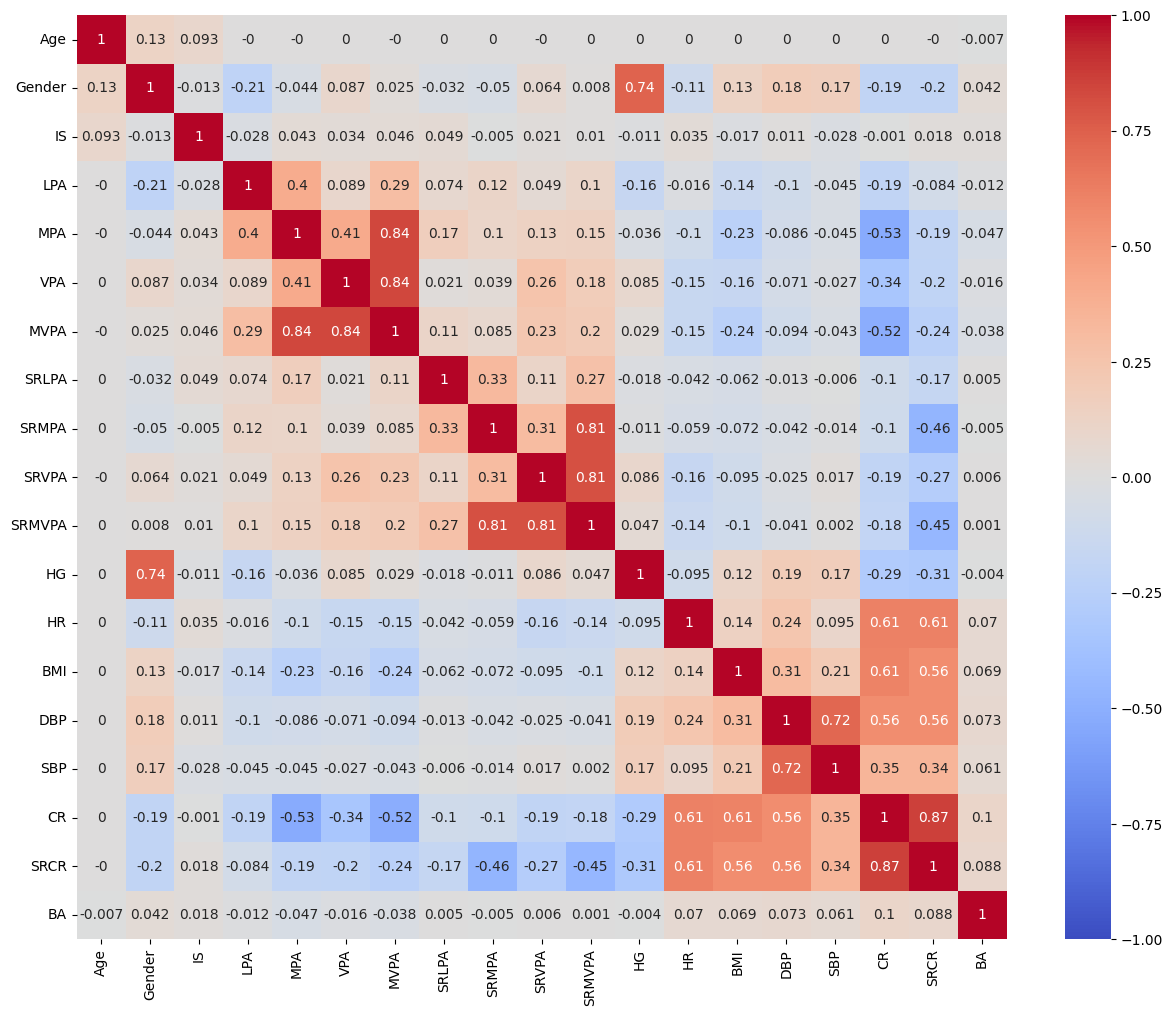

In [183]:
corr = main_test.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

## 4.1 Female

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'IS'),
  Text(0, 2.5, 'LPA'),
  Text(0, 3.5, 'MPA'),
  Text(0, 4.5, 'VPA'),
  Text(0, 5.5, 'MVPA'),
  Text(0, 6.5, 'SRLPA'),
  Text(0, 7.5, 'SRMPA'),
  Text(0, 8.5, 'SRVPA'),
  Text(0, 9.5, 'SRMVPA'),
  Text(0, 10.5, 'HG'),
  Text(0, 11.5, 'HR'),
  Text(0, 12.5, 'BMI'),
  Text(0, 13.5, 'DBP'),
  Text(0, 14.5, 'SBP'),
  Text(0, 15.5, 'CR'),
  Text(0, 16.5, 'SRCR'),
  Text(0, 17.5, 'BA')])

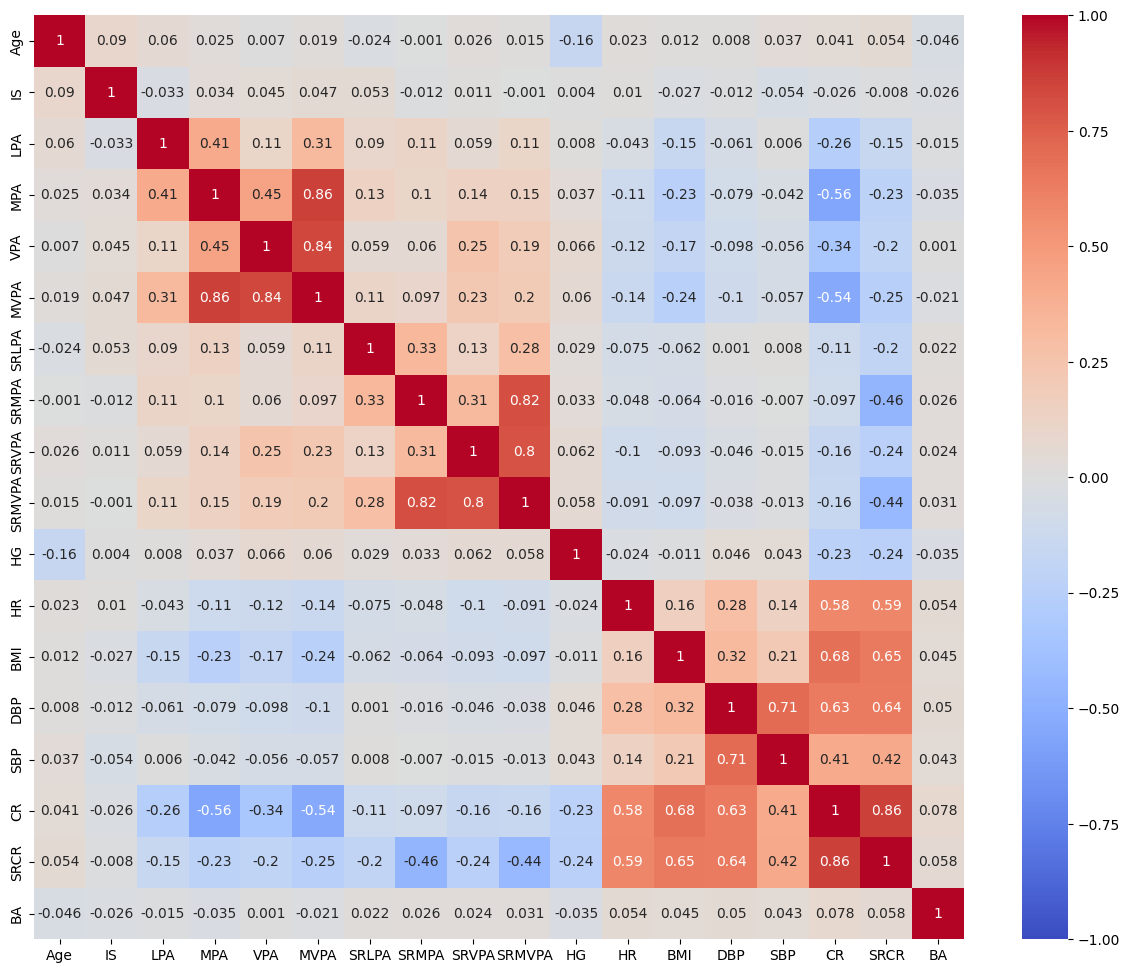

In [184]:
female = main_test[main_test["Gender"] == 0]
del female["Gender"]
corr = female.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

## 4.2 Male

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'IS'),
  Text(0, 2.5, 'LPA'),
  Text(0, 3.5, 'MPA'),
  Text(0, 4.5, 'VPA'),
  Text(0, 5.5, 'MVPA'),
  Text(0, 6.5, 'SRLPA'),
  Text(0, 7.5, 'SRMPA'),
  Text(0, 8.5, 'SRVPA'),
  Text(0, 9.5, 'SRMVPA'),
  Text(0, 10.5, 'HG'),
  Text(0, 11.5, 'HR'),
  Text(0, 12.5, 'BMI'),
  Text(0, 13.5, 'DBP'),
  Text(0, 14.5, 'SBP'),
  Text(0, 15.5, 'CR'),
  Text(0, 16.5, 'SRCR'),
  Text(0, 17.5, 'BA')])

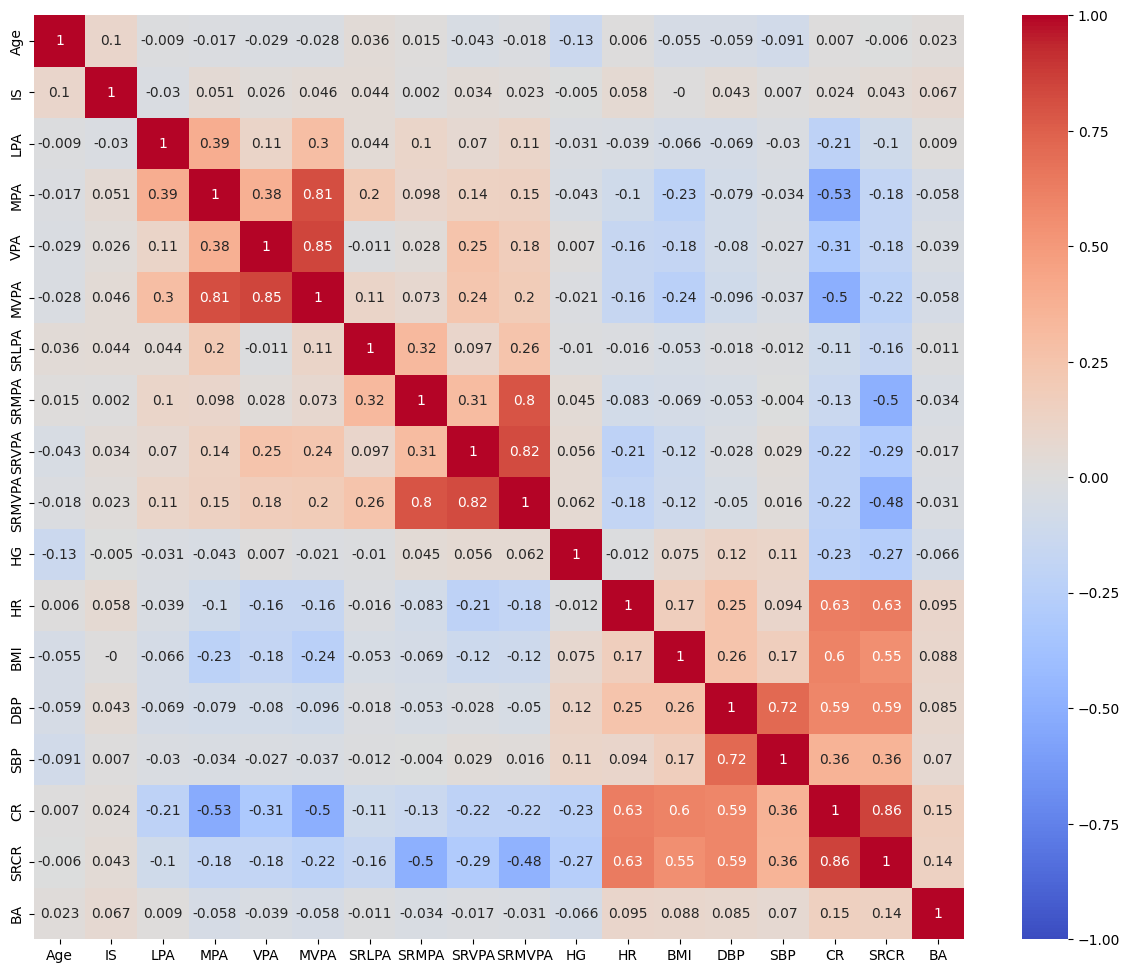

In [185]:
male = main_test[main_test["Gender"] == 1]
del male["Gender"]
corr = male.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

# 6 Models OLS

## 6.1 Single Predictor Models

### 6.1.1 Accelerometer PA

In [186]:
mpa = ols('BA ~ MPA + Gender + IS + Gender:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.976
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           8.53e-05
Time:                        19:43:46   Log-Likelihood:                -18302.
No. Observations:                5422   AIC:                         3.661e+04
Df Residuals:                    5417   BIC:                         3.665e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8918      0.230     -3.871      0.0

### 6.1.2 Self-report PA

In [187]:
srmpa = ols('BA ~ SRMPA + Gender + IS + Gender:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.041
Date:                Sat, 11 Mar 2023   Prob (F-statistic):            0.00283
Time:                        19:43:47   Log-Likelihood:                -18306.
No. Observations:                5422   AIC:                         3.662e+04
Df Residuals:                    5417   BIC:                         3.665e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.8840      0.231     -3.834   

### 6.1.3 Combined risk scores (Acc)

In [188]:
cr = ols('BA ~ CR + Gender + IS + Gender:CR', missing='drop', data = main_test).fit()
print(cr.summary())

#calculate effect size
results = cr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     22.28
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           2.88e-18
Time:                        19:43:48   Log-Likelihood:                -18270.
No. Observations:                5422   AIC:                         3.655e+04
Df Residuals:                    5417   BIC:                         3.658e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9612      0.231     -4.170      0.0

#### 6.1.3.1 Males

In [189]:
male = main_test[main_test["Gender"] == 1]

crm = ols('BA ~ CR + IS', missing='drop', data = male).fit()
print(crm.summary())

#calculate effect size
results = crm
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     34.30
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           2.01e-15
Time:                        19:43:48   Log-Likelihood:                -8556.7
No. Observations:                2524   AIC:                         1.712e+04
Df Residuals:                    2521   BIC:                         1.714e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6923      0.315     -2.200      0.0

#### 6.1.3.2 Females

In [190]:
female = main_test[main_test["Gender"] == 0]

crf = ols('BA ~ CR + IS', missing='drop', data = female).fit()
print(crf.summary())

#calculate effect size
results = crf
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.837
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           5.52e-05
Time:                        19:43:49   Log-Likelihood:                -9705.3
No. Observations:                2898   AIC:                         1.942e+04
Df Residuals:                    2895   BIC:                         1.943e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3844      0.284     -1.354      0.1

### 6.1.4 Combined risk score (SR)

In [191]:
srcr = ols('BA ~ SRCR + Gender + IS + Gender:SRCR', missing='drop', data = main_test).fit()
print(srcr.summary())

#calculate effect size
results = srcr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     18.78
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           2.41e-15
Time:                        19:43:49   Log-Likelihood:                -18277.
No. Observations:                5422   AIC:                         3.656e+04
Df Residuals:                    5417   BIC:                         3.660e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.9090      0.231     -3.940      

## 6.2 Multiple Predictor & Comparison Models

### 6.2.1 Covariates

In [192]:
cov_model = ols('BA ~ Gender + Age + IS', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.104
Date:                Sat, 11 Mar 2023   Prob (F-statistic):            0.00642
Time:                        19:43:49   Log-Likelihood:                -18308.
No. Observations:                5422   AIC:                         3.662e+04
Df Residuals:                    5418   BIC:                         3.665e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0486      0.814     -0.060      0.9

### 6.2.2 CR / MPA

In [193]:
no_mpa = ols('BA ~ HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_mpa.summary())

#calculate effect size
results = no_mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     8.953
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           9.00e-15
Time:                        19:43:49   Log-Likelihood:                -18269.
No. Observations:                5422   AIC:                         3.656e+04
Df Residuals:                    5411   BIC:                         3.663e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0955      0.278     -3.934      0.0

### 6.2.3 CR / HG

In [194]:
no_hg = ols('BA ~ MPA + DBP + HR + BMI + Gender + IS + MPA:Gender + DBP:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_hg.summary())

#calculate effect size
results = no_hg
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     7.447
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           7.38e-12
Time:                        19:43:49   Log-Likelihood:                -18277.
No. Observations:                5422   AIC:                         3.658e+04
Df Residuals:                    5411   BIC:                         3.665e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8242      0.232     -3.559      0.0

### 6.2.4 CR / HR

In [195]:
no_hr = ols('BA ~ HG + DBP + MPA + BMI + Gender + IS + HG:Gender + DBP:Gender + MPA:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_hr.summary())

#calculate effect size
results = no_hr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     8.006
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           6.19e-13
Time:                        19:43:50   Log-Likelihood:                -18274.
No. Observations:                5422   AIC:                         3.657e+04
Df Residuals:                    5411   BIC:                         3.664e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0973      0.278     -3.942      0.0

### 6.2.5 CR / DBP

In [196]:
no_dbp = ols('BA ~ HG + MPA + HR + BMI + Gender + IS + HG:Gender + MPA:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_dbp.summary())

#calculate effect size
results = no_dbp
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     8.353
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           1.32e-13
Time:                        19:43:50   Log-Likelihood:                -18272.
No. Observations:                5422   AIC:                         3.657e+04
Df Residuals:                    5411   BIC:                         3.664e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1372      0.278     -4.085      0.0

### 6.2.6 CR / BMI

In [197]:
no_bmi = ols('BA ~ HG + DBP + HR + MPA + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + MPA:Gender', missing='drop', data = main_test).fit()
print(no_bmi.summary())

#calculate effect size
results = no_bmi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     8.427
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           9.47e-14
Time:                        19:43:50   Log-Likelihood:                -18272.
No. Observations:                5422   AIC:                         3.657e+04
Df Residuals:                    5411   BIC:                         3.664e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1130      0.279     -3.995      0.0

### 6.2.7 CR

In [198]:
cr2 = ols('BA ~ MPA +HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender + MPA:Gender', missing='drop', data = main_test).fit()
print(cr2.summary())

#calculate effect size
results = cr2
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     7.862
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           9.80e-15
Time:                        19:43:50   Log-Likelihood:                -18267.
No. Observations:                5422   AIC:                         3.656e+04
Df Residuals:                    5409   BIC:                         3.665e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1042      0.279     -3.964      0.0

### 6.2.8 SRCR

In [199]:
srcr2 = ols('BA ~ SRMPA + HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender + SRMPA:Gender', missing='drop', data = main_test).fit()
print(srcr2.summary())

#calculate effect size
results = srcr2
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     7.762
Date:                Sat, 11 Mar 2023   Prob (F-statistic):           1.67e-14
Time:                        19:43:50   Log-Likelihood:                -18268.
No. Observations:                5422   AIC:                         3.656e+04
Df Residuals:                    5409   BIC:                         3.665e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.1176      0.279     -4.010   

# 7 Model comparisons

## 7.1 Cov vs. PA

In [200]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  271983.194876      0.0         NaN       NaN       NaN
1    5417.0  271403.595138      1.0  579.599738  11.56835  0.000676


## 7.2 Cov vs. SRPA

In [201]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  271983.194876      0.0         NaN       NaN       NaN
1    5417.0  271790.230731      1.0  192.964145  3.845932  0.049918


## 7.3 CR / MPA

In [202]:
model_comparison = anova_lm(no_mpa, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  268164.291464      0.0         NaN       NaN       NaN
1    5409.0  267928.005088      2.0  236.286376  2.385105  0.092176


## 7.4 SRCR / SRMPA

In [203]:
model_comparison = anova_lm(no_mpa, srcr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  268164.291464      0.0         NaN       NaN       NaN
1    5409.0  267986.786387      2.0  177.505076  1.791366  0.166831


## 7.5 CR / HG

In [204]:
model_comparison = anova_lm(no_hg, cr2)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5411.0  268900.355548      0.0        NaN       NaN       NaN
1    5409.0  267928.005088      2.0  972.35046  9.815032  0.000056


## 7.6 CR / DBP

In [205]:
model_comparison = anova_lm(no_dbp, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  268456.865172      0.0         NaN       NaN       NaN
1    5409.0  267928.005088      2.0  528.860084  5.338382  0.004829


## 7.7 CR / HR

In [206]:
model_comparison = anova_lm(no_hr, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  268626.621699      0.0         NaN       NaN       NaN
1    5409.0  267928.005088      2.0  698.616611  7.051927  0.000874


## 7.8 CR / BMI

In [207]:
model_comparison = anova_lm(no_bmi, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F   Pr(>F)
0    5411.0  268420.718873      0.0         NaN       NaN      NaN
1    5409.0  267928.005088      2.0  492.713785  4.973517  0.00695


## 7.9 CR Female vs. Male

In [208]:
model_comparison = anova_lm(crf, crm)
print(model_comparison)

   df_resid            ssr  df_diff      ss_diff         F  Pr(>F)
0    2895.0  137562.583378      0.0          NaN       NaN     NaN
1    2521.0  130092.336993    374.0  7470.246385  0.387065     1.0


# 8 Mediation analysis

## 8.1 PA x Health / Fitness

### 8.1.1 BMI

In [209]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.065808       -0.102717       -0.036144    0.000
ACME (treated)           -0.065808       -0.102717       -0.036144    0.000
ADE (control)            -0.021351       -0.207783        0.163118    0.834
ADE (treated)            -0.021351       -0.207783        0.163118    0.834
Total effect             -0.087159       -0.270711        0.096435    0.376
Prop. mediated (control)  0.481785       -9.685602        6.288322    0.376
Prop. mediated (treated)  0.481785       -9.685602        6.288322    0.376
ACME (average)           -0.065808       -0.102717       -0.036144    0.000
ADE (average)            -0.021351       -0.207783        0.163118    0.834
Prop. mediated (average)  0.481785       -9.685602        6.288322    0.376


In [210]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

KeyboardInterrupt: 

In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.080080       -0.121769       -0.043213    0.000
ACME (treated)           -0.080080       -0.121769       -0.043213    0.000
ADE (control)            -0.033953       -0.228023        0.152107    0.744
ADE (treated)            -0.033953       -0.228023        0.152107    0.744
Total effect             -0.114033       -0.307045        0.075631    0.252
Prop. mediated (control)  0.547409       -6.553345        6.707679    0.252
Prop. mediated (treated)  0.547409       -6.553345        6.707679    0.252
ACME (average)           -0.080080       -0.121769       -0.043213    0.000
ADE (average)            -0.033953       -0.228023        0.152107    0.744
Prop. mediated (average)  0.547409       -6.553345        6.707679    0.252


### 8.1.2 DBP

In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.051812       -0.086779       -0.023671    0.000
ACME (treated)           -0.051812       -0.086779       -0.023671    0.000
ADE (control)            -0.032203       -0.219007        0.146829    0.734
ADE (treated)            -0.032203       -0.219007        0.146829    0.734
Total effect             -0.084015       -0.273393        0.097347    0.398
Prop. mediated (control)  0.376450       -4.943974        6.933479    0.398
Prop. mediated (treated)  0.376450       -4.943974        6.933479    0.398
ACME (average)           -0.051812       -0.086779       -0.023671    0.000
ADE (average)            -0.032203       -0.219007        0.146829    0.734
Prop. mediated (average)  0.376450       -4.943974        6.933479    0.398


In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.043443       -0.075438       -0.016848    0.000
ACME (treated)           -0.043443       -0.075438       -0.016848    0.000
ADE (control)            -0.304043       -0.495299       -0.110930    0.002
ADE (treated)            -0.304043       -0.495299       -0.110930    0.002
Total effect             -0.347486       -0.540115       -0.157246    0.000
Prop. mediated (control)  0.123722        0.050652        0.299964    0.000
Prop. mediated (treated)  0.123722        0.050652        0.299964    0.000
ACME (average)           -0.043443       -0.075438       -0.016848    0.000
ADE (average)            -0.304043       -0.495299       -0.110930    0.002
Prop. mediated (average)  0.123722        0.050652        0.299964    0.000


In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.036498       -0.066555       -0.012638    0.002
ACME (treated)           -0.036498       -0.066555       -0.012638    0.002
ADE (control)            -0.076746       -0.276022        0.123515    0.428
ADE (treated)            -0.076746       -0.276022        0.123515    0.428
Total effect             -0.113244       -0.318103        0.084172    0.262
Prop. mediated (control)  0.243363       -3.836258        2.097319    0.264
Prop. mediated (treated)  0.243363       -3.836258        2.097319    0.264
ACME (average)           -0.036498       -0.066555       -0.012638    0.002
ADE (average)            -0.076746       -0.276022        0.123515    0.428
Prop. mediated (average)  0.243363       -3.836258        2.097319    0.264


### 8.1.3 Heart rate

In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ HR + LPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.008211       -0.033173        0.014319    0.512
ACME (treated)           -0.008211       -0.033173        0.014319    0.512
ADE (control)            -0.074309       -0.261759        0.116109    0.434
ADE (treated)            -0.074309       -0.261759        0.116109    0.434
Total effect             -0.082520       -0.280237        0.111186    0.380
Prop. mediated (control)  0.061375       -1.252801        1.565353    0.624
Prop. mediated (treated)  0.061375       -1.252801        1.565353    0.624
ACME (average)           -0.008211       -0.033173        0.014319    0.512
ADE (average)            -0.074309       -0.261759        0.116109    0.434
Prop. mediated (average)  0.061375       -1.252801        1.565353    0.624


In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.047765       -0.080836       -0.022483      0.0
ACME (treated)           -0.047765       -0.080836       -0.022483      0.0
ADE (control)            -0.293154       -0.493280       -0.110112      0.0
ADE (treated)            -0.293154       -0.493280       -0.110112      0.0
Total effect             -0.340919       -0.537535       -0.158180      0.0
Prop. mediated (control)  0.138364        0.060506        0.337998      0.0
Prop. mediated (treated)  0.138364        0.060506        0.337998      0.0
ACME (average)           -0.047765       -0.080836       -0.022483      0.0
ADE (average)            -0.293154       -0.493280       -0.110112      0.0
Prop. mediated (average)  0.138364        0.060506        0.337998      0.0


In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ HR + VPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.075240       -0.114619       -0.040312    0.000
ACME (treated)           -0.075240       -0.114619       -0.040312    0.000
ADE (control)            -0.043252       -0.229374        0.151633    0.684
ADE (treated)            -0.043252       -0.229374        0.151633    0.684
Total effect             -0.118492       -0.304297        0.084155    0.240
Prop. mediated (control)  0.477673       -5.607413        5.380320    0.240
Prop. mediated (treated)  0.477673       -5.607413        5.380320    0.240
ACME (average)           -0.075240       -0.114619       -0.040312    0.000
ADE (average)            -0.043252       -0.229374        0.151633    0.684
Prop. mediated (average)  0.477673       -5.607413        5.380320    0.240


### 8.1.4 Hand grip

In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ HG + LPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.006914       -0.022611        0.039074    0.644
ACME (treated)            0.006914       -0.022611        0.039074    0.644
ADE (control)            -0.089312       -0.278986        0.102823    0.400
ADE (treated)            -0.089312       -0.278986        0.102823    0.400
Total effect             -0.082397       -0.266598        0.103135    0.424
Prop. mediated (control) -0.032009       -2.261339        1.349535    0.784
Prop. mediated (treated) -0.032009       -2.261339        1.349535    0.784
ACME (average)            0.006914       -0.022611        0.039074    0.644
ADE (average)            -0.089312       -0.278986        0.102823    0.400
Prop. mediated (average) -0.032009       -2.261339        1.349535    0.784


In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.001834       -0.006691        0.011745    0.648
ACME (treated)            0.001834       -0.006691        0.011745    0.648
ADE (control)            -0.340553       -0.531596       -0.158139    0.000
ADE (treated)            -0.340553       -0.531596       -0.158139    0.000
Total effect             -0.338719       -0.525930       -0.156369    0.000
Prop. mediated (control) -0.003161       -0.040475        0.024513    0.648
Prop. mediated (treated) -0.003161       -0.040475        0.024513    0.648
ACME (average)            0.001834       -0.006691        0.011745    0.648
ADE (average)            -0.340553       -0.531596       -0.158139    0.000
Prop. mediated (average) -0.003161       -0.040475        0.024513    0.648


In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ HG + VPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.001648       -0.019916        0.016357    0.820
ACME (treated)           -0.001648       -0.019916        0.016357    0.820
ADE (control)            -0.114926       -0.313469        0.070907    0.218
ADE (treated)            -0.114926       -0.313469        0.070907    0.218
Total effect             -0.116574       -0.314740        0.064015    0.216
Prop. mediated (control)  0.010295       -0.494903        0.546957    0.868
Prop. mediated (treated)  0.010295       -0.494903        0.546957    0.868
ACME (average)           -0.001648       -0.019916        0.016357    0.820
ADE (average)            -0.114926       -0.313469        0.070907    0.218
Prop. mediated (average)  0.010295       -0.494903        0.546957    0.868


# 9 LASSO Regression

## 9.1 Accelerometer PA

In [ ]:
df = main_test[["Age", "Gender", "IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

# lasso with cross validated alpha

lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_

# Print the coefficients
print(coefficients)

KeyError: "['IS'] not in index"

### 9.1.1 Females only

<Figure size 1200x900 with 0 Axes>

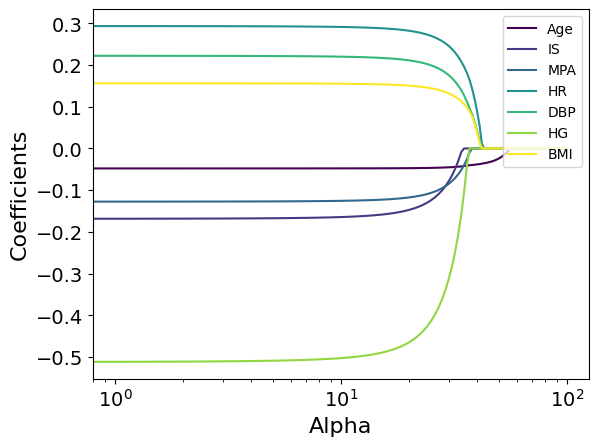

In [ ]:
female = main_test[main_test["Gender"]==0]
df = female[["Age", "Gender", "IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

### 9.1.2 Males only

<Figure size 1200x900 with 0 Axes>

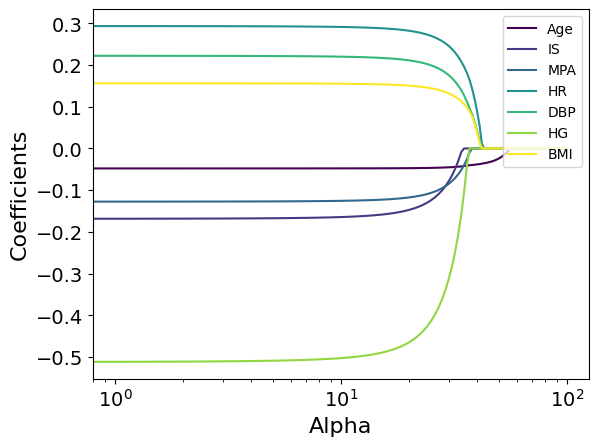

In [ ]:
male = main_test[main_test["Gender"]==1]
df = female[["Age", "Gender", "IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

## 9.2 Self-report PA

<Figure size 1200x900 with 0 Axes>

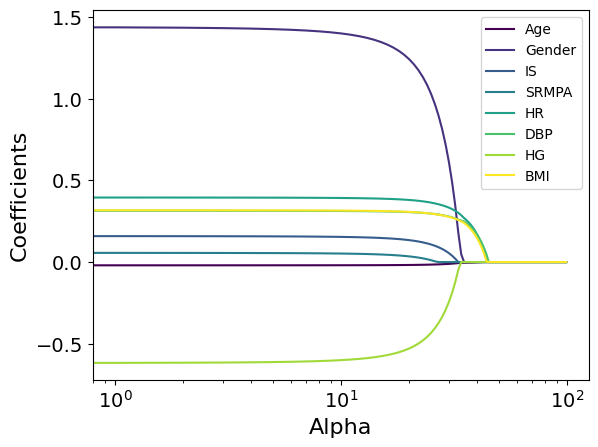

[-0.01977951  1.42499072  0.1572111   0.05494194  0.39400475  0.31343528
 -0.61183981  0.31633614]


In [ ]:
df = main_test[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_

# Print the coefficients
print(coefficients)

# 10 Figures for Paper

## 10.1 Scatterplot BrainAGE x Combined risk score

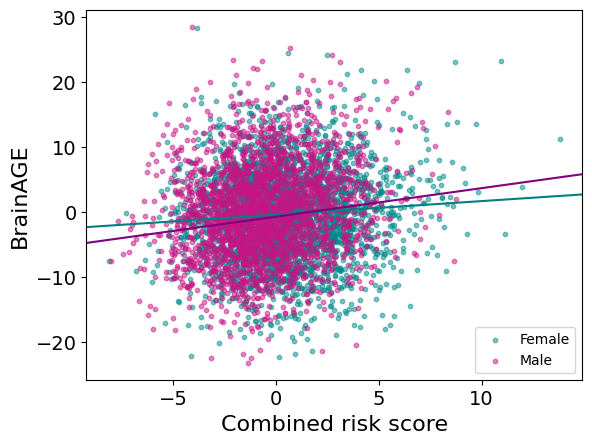

In [ ]:
plt.figure()
plt.scatter("CR", "BA", data = female, label = "Female", alpha=0.5, s=10, color = "darkcyan")
plt.scatter("CR", "BA", data = male, label = "Male", alpha=0.5, s=10, color = "mediumvioletred")
plt.ylabel("BrainAGE", fontsize = 16)
plt.xlabel("Combined risk score", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc="best")
plt.axline((0,-0.38), slope=0.208, color="teal")
plt.axline((0,-0.69), slope=0.438, color="purple")
plt.show()

## 10.2 Smaller Correlation Heatmap

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'Gender'),
  Text(0, 2.5, 'MPA'),
  Text(0, 3.5, 'SRMPA'),
  Text(0, 4.5, 'HG'),
  Text(0, 5.5, 'HR'),
  Text(0, 6.5, 'BMI'),
  Text(0, 7.5, 'DBP'),
  Text(0, 8.5, 'CR'),
  Text(0, 9.5, 'SRCR'),
  Text(0, 10.5, 'BA')])

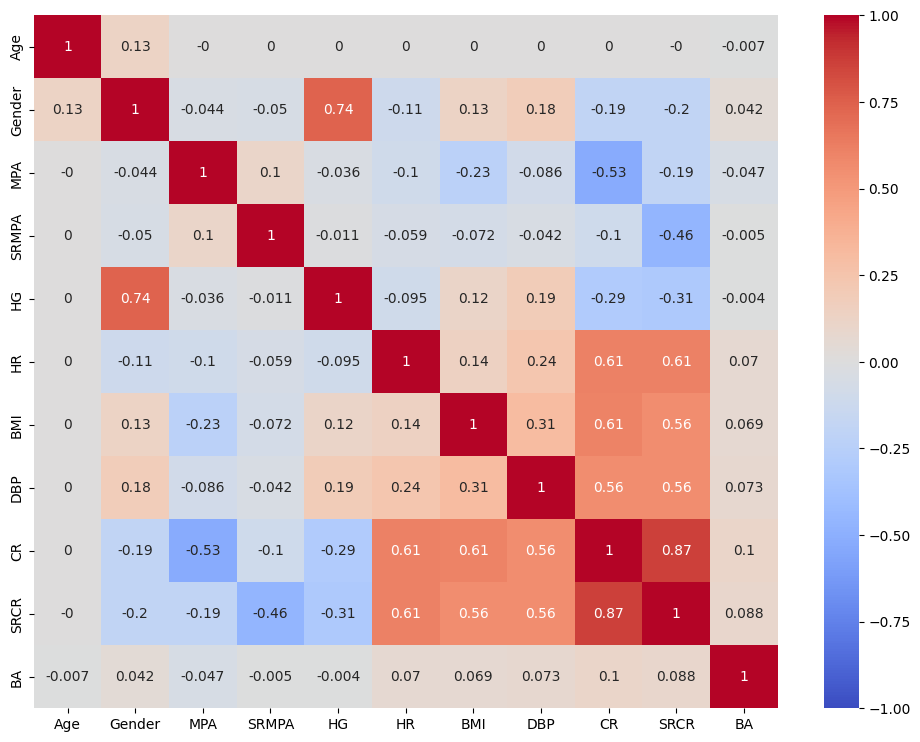

In [ ]:
x = main_test
del x["IS"]
del x["LPA"]
del x["VPA"]
del x["SRLPA"]
del x["SRVPA"]
del x["SBP"]
del x["MVPA"]
del x["SRMVPA"]

corr = x.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(12,9)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

### 10.2.1 Females only

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'MPA'),
  Text(0, 2.5, 'SRMPA'),
  Text(0, 3.5, 'HG'),
  Text(0, 4.5, 'HR'),
  Text(0, 5.5, 'BMI'),
  Text(0, 6.5, 'DBP'),
  Text(0, 7.5, 'CR'),
  Text(0, 8.5, 'SRCR'),
  Text(0, 9.5, 'BA')])

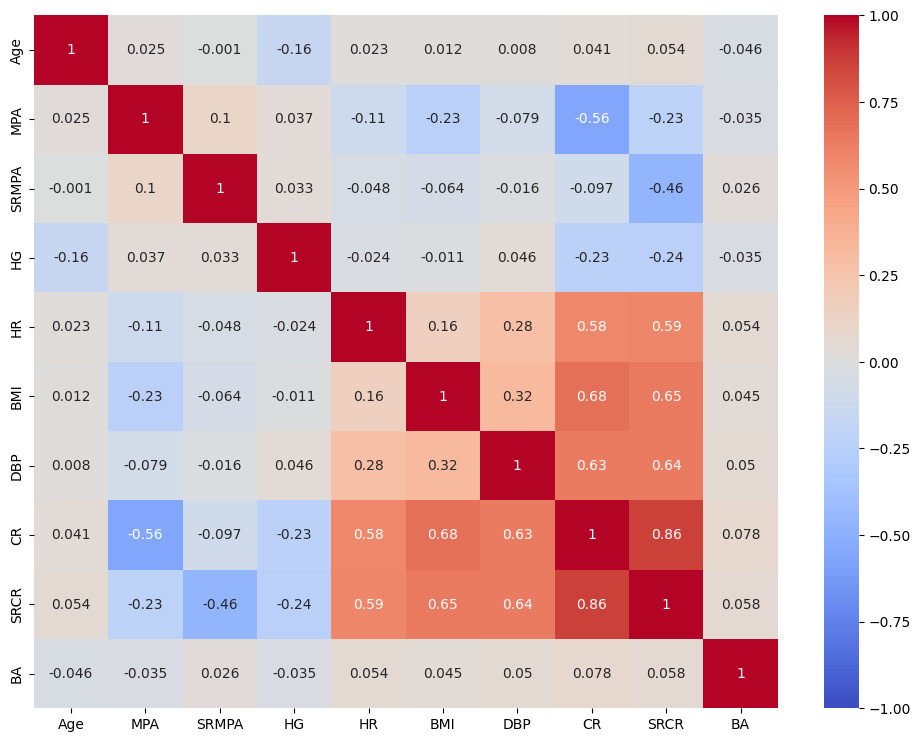

In [ ]:
female = x[x["Gender"] == 0]
del female["Gender"]
corr = female.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(12,9)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

### 10.2.2 Males only

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'MPA'),
  Text(0, 2.5, 'SRMPA'),
  Text(0, 3.5, 'HG'),
  Text(0, 4.5, 'HR'),
  Text(0, 5.5, 'BMI'),
  Text(0, 6.5, 'DBP'),
  Text(0, 7.5, 'CR'),
  Text(0, 8.5, 'SRCR'),
  Text(0, 9.5, 'BA')])

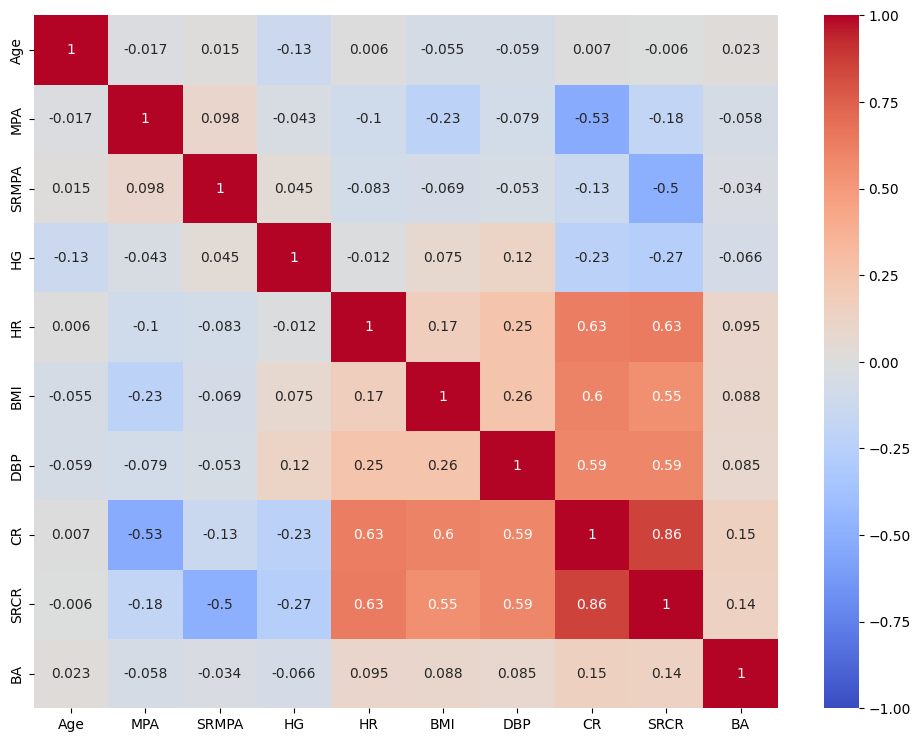

In [ ]:
male = x[x["Gender"] == 1]
del male["Gender"]
corr = male.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(12,9)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

# 11 Exploration vs. Validation

## 11.1 Import processed Validation set

In [ ]:
validate = pd.read_pickle("3_validate.pkl")
validate = pd.DataFrame(validate)

## 11.2 BrainAGE distribution

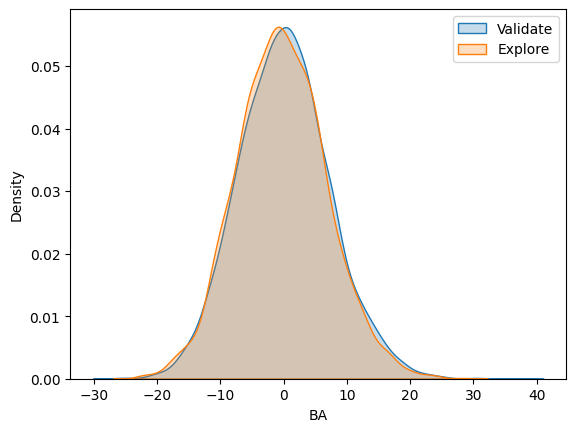

In [ ]:
plt.figure()
sns.kdeplot(data = validate, x= 'BA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'BA', fill=True, label = "Explore")
plt.legend(loc="best")
plt.show()

## 11.3 MPA distribution

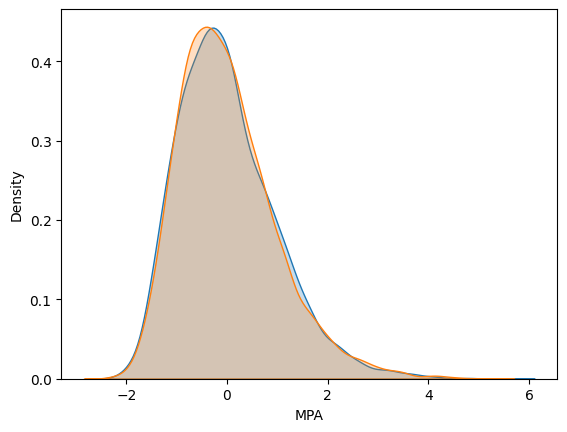

In [ ]:
plt.figure()
sns.kdeplot(data = validate, x= 'MPA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Explore")
plt.show()